TARGET: WiFi Fault

Accuracy for WiFi Fault: 0.8550

Classification Report for WiFi Fault:

                          precision    recall  f1-score   support

                 Bending       0.82      0.86      0.84        70
             Body_Effect       0.91      0.91      0.91        94
Conductivity_Degradation       0.86      0.81      0.84        70
                  Cracks       0.82      0.87      0.85        69
          Humidity_Sweat       0.79      0.86      0.82        71
                No_Fault       1.00      0.33      0.50         6
         Rupture_Coupure       0.84      0.86      0.85        85
          Strong_Flexion       0.92      0.84      0.88        73

                accuracy                           0.86       538
               macro avg       0.87      0.79      0.81       538
            weighted avg       0.86      0.86      0.85       538



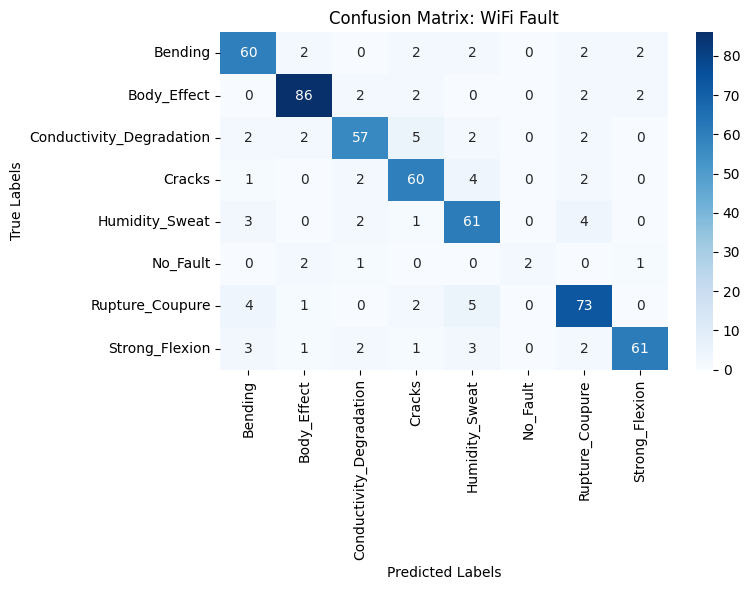


Feature Importances for WiFi Fault:

Bandwidth       0.081072
Efficiency      0.079734
S11             0.079405
Length          0.079219
Gain            0.078321
Feed            0.078118
Conductivity    0.077811
VSWR            0.076993
Width           0.076890
Bend            0.075667
Height          0.073099
Permittivity    0.072234
epsilon_r       0.071438


/tmp/ipykernel_55/3480518408.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


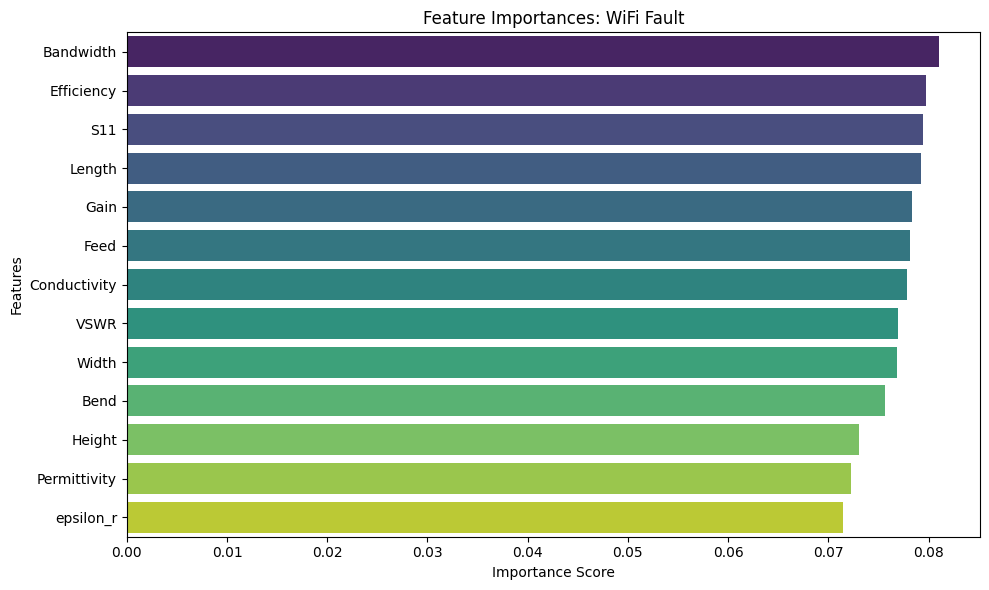




TARGET: BT Fault

Accuracy for BT Fault: 0.8848

Classification Report for BT Fault:

                          precision    recall  f1-score   support

                 Bending       0.88      0.97      0.92        65
             Body_Effect       0.88      0.82      0.85        62
Conductivity_Degradation       0.89      0.85      0.87        55
                 Coupure       0.86      0.86      0.86        59
                  Cracks       0.87      0.85      0.86        54
       Humidity_or_Sweat       0.92      0.87      0.89        63
                No_Fault       1.00      1.00      1.00        76
                 Rupture       0.78      0.81      0.80        58
          Strong_Flexion       0.85      0.87      0.86        46

                accuracy                           0.88       538
               macro avg       0.88      0.88      0.88       538
            weighted avg       0.89      0.88      0.88       538



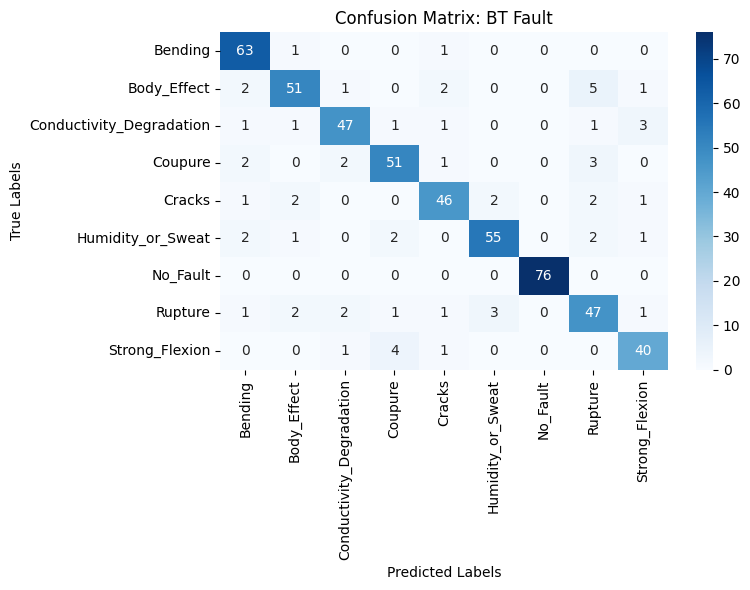


Feature Importances for BT Fault:

VSWR            0.099266
Efficiency      0.091506
S11             0.090791
Gain            0.088350
Bandwidth       0.086955
Width           0.071496
Feed            0.071433
Bend            0.070505
Conductivity    0.070155
Length          0.067399
epsilon_r       0.066763
Height          0.063000
Permittivity    0.062381


/tmp/ipykernel_55/3480518408.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


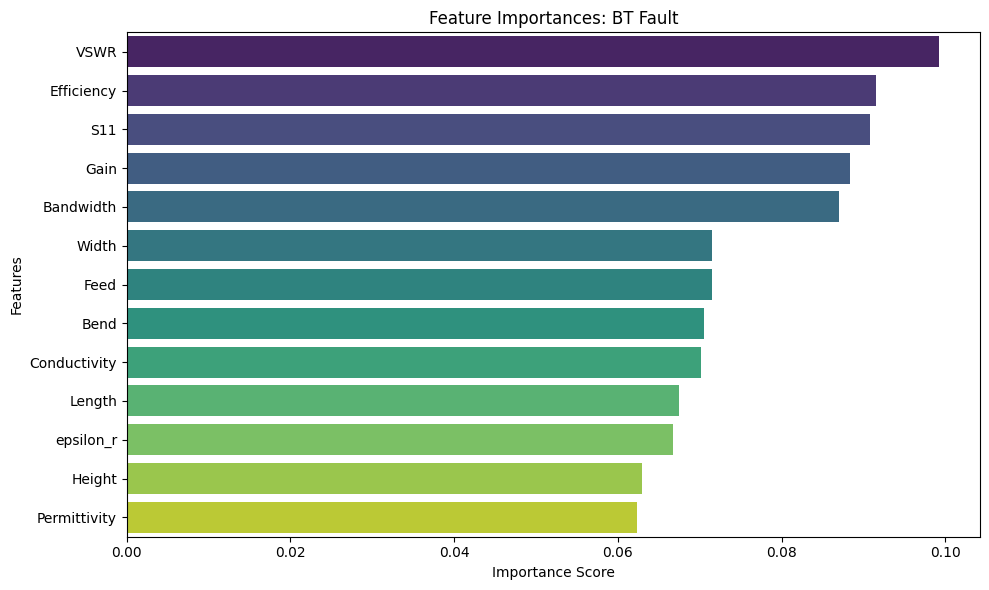




TARGET: WiFi Status

Accuracy for WiFi Status: 0.9944

Classification Report for WiFi Status:

              precision    recall  f1-score   support

       Fault       0.99      1.00      1.00       532
      Normal       1.00      0.50      0.67         6

    accuracy                           0.99       538
   macro avg       1.00      0.75      0.83       538
weighted avg       0.99      0.99      0.99       538



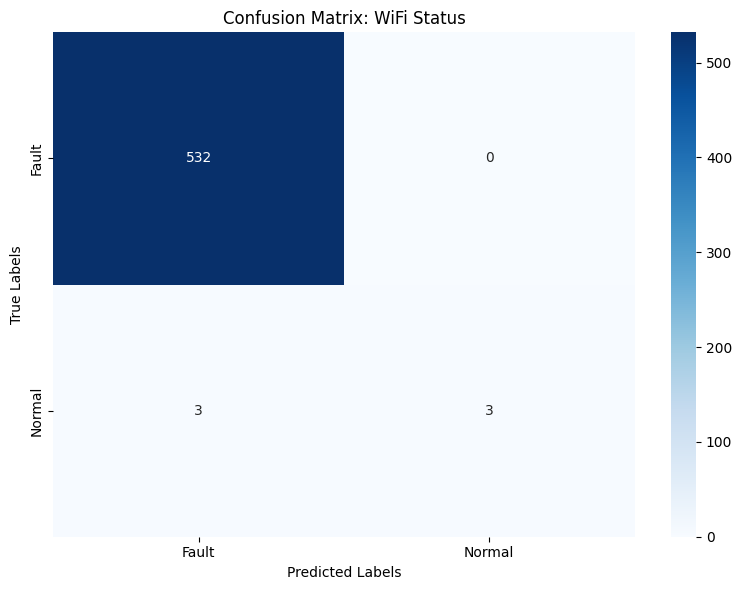


Feature Importances for WiFi Status:

Efficiency      0.161240
Bandwidth       0.136944
S11             0.134773
VSWR            0.125894
Gain            0.110517
Conductivity    0.054741
Height          0.044427
Width           0.043227
Feed            0.042844
Length          0.040940
epsilon_r       0.037845
Permittivity    0.036451
Bend            0.030157


/tmp/ipykernel_55/3480518408.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


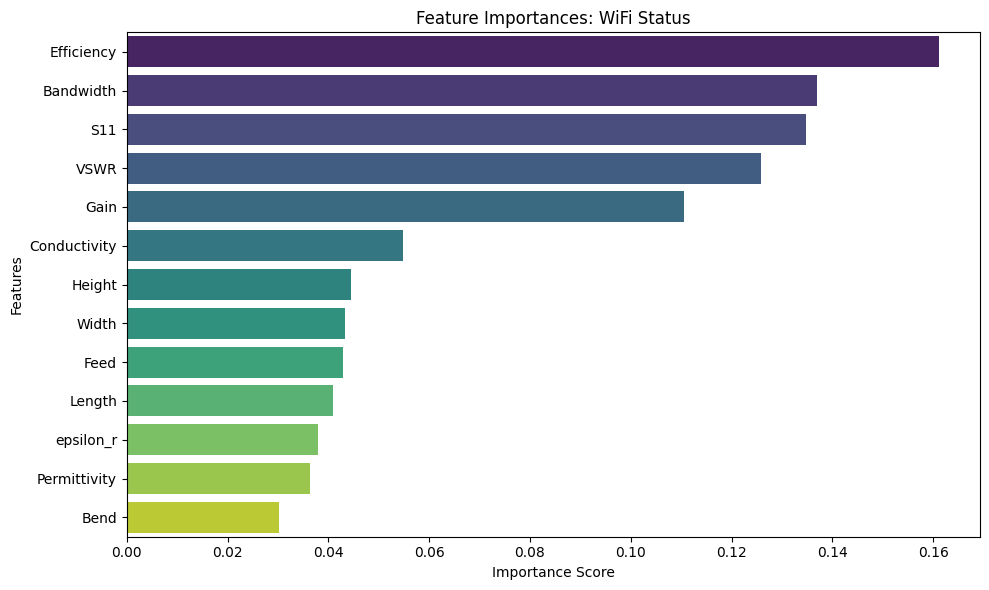




TARGET: BT Status

Accuracy for BT Status: 1.0000

Classification Report for BT Status:

              precision    recall  f1-score   support

       Fault       1.00      1.00      1.00       462
      Normal       1.00      1.00      1.00        76

    accuracy                           1.00       538
   macro avg       1.00      1.00      1.00       538
weighted avg       1.00      1.00      1.00       538



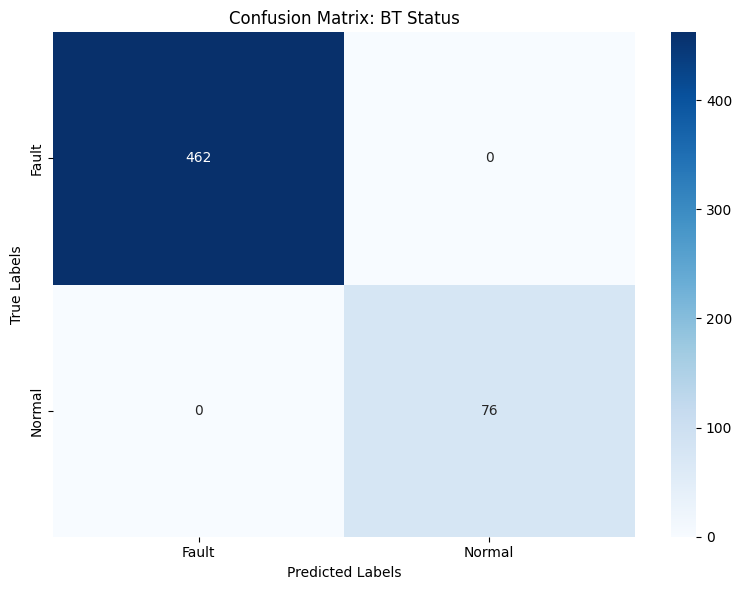


Feature Importances for BT Status:

VSWR            0.231756
Bandwidth       0.153710
Gain            0.152894
Efficiency      0.142275
S11             0.134027
Conductivity    0.030252
Length          0.023598
Permittivity    0.022903
Bend            0.022822
Feed            0.021950
Width           0.021569
Height          0.021174
epsilon_r       0.021069


/tmp/ipykernel_55/3480518408.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


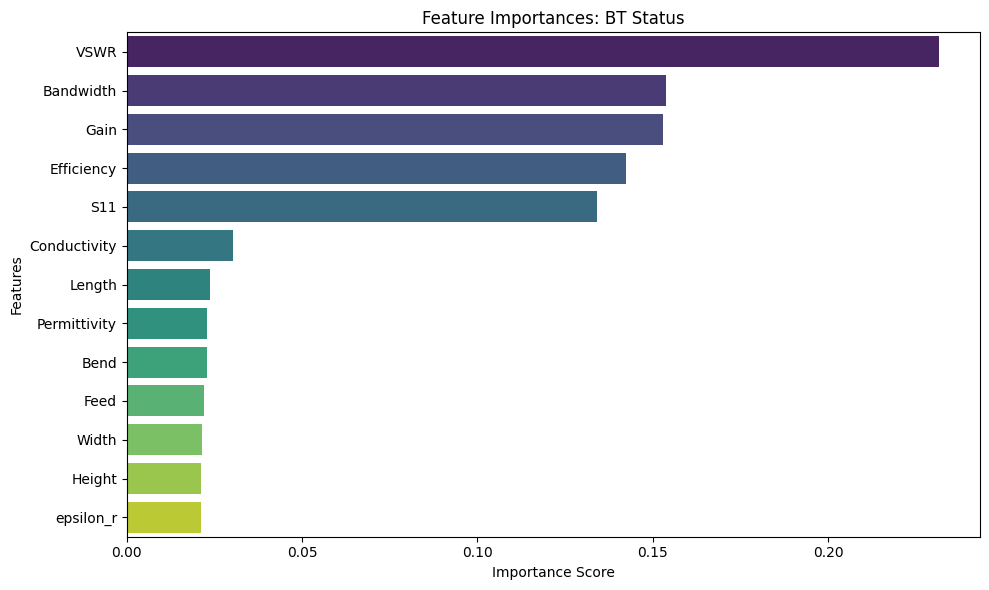

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# 1. Load the dataset
file_path = '/kaggle/input/datasets/amineipad/antenna-performance-and-fault-detection-dataset/antenna_fault.csv'
df = pd.read_csv(file_path)

# 2. Define targets and feature set
targets = ['WiFi Fault', 'BT Fault', 'WiFi Status', 'BT Status']
X = df.drop(columns=targets)

# Preprocess categorical features in X if there are any (failsafe)
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

# 3. Iterate over each target, build a model, evaluate, and plot
for target in targets:
    print("="*80)
    print(f"TARGET: {target}")
    print("="*80)
    
    # Drop rows where target might be NaN just to be safe
    valid_idx = df[target].dropna().index
    X_valid = X.loc[valid_idx]
    y_valid = df.loc[valid_idx, target]
    
    # Encode the target labels
    le_y = LabelEncoder()
    y_encoded = le_y.fit_transform(y_valid.astype(str))
    
    # Train-test split (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X_valid, y_encoded, test_size=0.2, random_state=42)
    
    # Initialize and train the model (Random Forest is great for feature importance)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    
    # --- PRINT ACCURACY ---
    acc = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy for {target}: {acc:.4f}\n")
    
    # --- PRINT CLASSIFICATION REPORT ---
    print(f"Classification Report for {target}:\n")
    print(classification_report(y_test, y_pred, target_names=le_y.classes_))
    
    # --- PLOT CONFUSION MATRIX (SEABORN) ---
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=le_y.classes_, yticklabels=le_y.classes_)
    plt.title(f'Confusion Matrix: {target}')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.tight_layout()
    plt.show()
    
    # --- PRINT FEATURE IMPORTANCE ---
    feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print(f"\nFeature Importances for {target}:\n")
    print(feature_importances.to_string())
    
    # --- PLOT FEATURE IMPORTANCE ---
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
    plt.title(f'Feature Importances: {target}')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()
    
    print("\n\n")